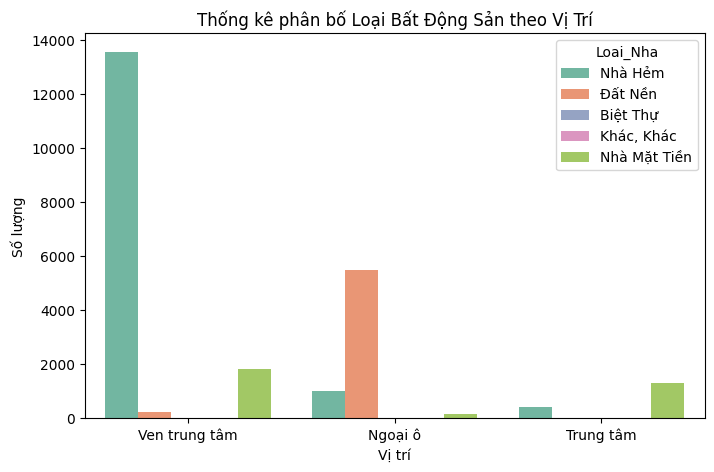

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Đọc dữ liệu từ file Excel đã được làm sạch
df_clean = pd.read_excel('DataClearn.xlsx')

# Trực quan hóa phân bố loại nhà theo khu vực
plt.figure(figsize=(8, 5))
sns.countplot(data=df_clean, x='Vi_tri', hue='Loai_Nha', palette='Set2')
plt.title('Thống kê phân bố Loại Bất Động Sản theo Vị Trí')
plt.xlabel('Vị trí')
plt.ylabel('Số lượng')
plt.show()

In [2]:
!pip install prince
import prince

# Khởi tạo mô hình MCA
mca = prince.MCA(
    n_components=2, # Giữ lại 2 chiều để dễ trực quan hóa
    n_iter=3,
    copy=True,
    check_input=True,
    engine='sklearn', # Đã sửa 'auto' thành 'sklearn'
    random_state=42
)

# Huấn luyện và trích xuất tọa độ
mca = mca.fit(df_clean)
house_coordinates = mca.row_coordinates(df_clean)
house_coordinates.columns = ['Dim_1', 'Dim_2']
display(house_coordinates.head())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 5.0 MB/s eta 0:00:00


,Dim_1,Dim_2
0,-0.363685,-0.467671
1,-0.363685,-0.467671
2,-0.363685,-0.467671
3,-0.363685,-0.467671
4,-0.363685,-0.467671


In [22]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

# Tính Silhouette cho k=3
kmeans_3 = KMeans(n_clusters=3, random_state=42).fit(house_coordinates)
sil_3 = silhouette_score(house_coordinates, kmeans_3.labels_)

# Tính Silhouette cho k=4
kmeans_4 = KMeans(n_clusters=4, random_state=42).fit(house_coordinates)
sil_4 = silhouette_score(house_coordinates, kmeans_4.labels_)

print(f"Silhouette Score (k=3): {sil_3:.4f}")
print(f"Silhouette Score (k=4): {sil_4:.4f}")

Silhouette Score (k=3): 0.7279
Silhouette Score (k=4): 0.5882


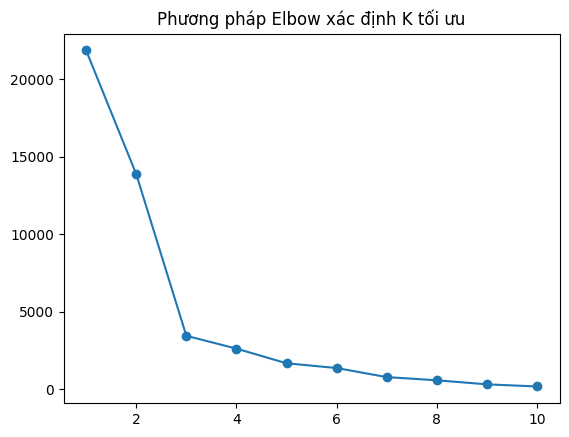

In [24]:
from sklearn.cluster import KMeans

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(house_coordinates)
    wcss.append(kmeans.inertia_)

# Vẽ biểu đồ Elbow
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Phương pháp Elbow xác định K tối ưu')
plt.show()

In [ ]:
from sklearn.cluster import KMeans
import pandas as pd

# 1. Áp dụng K-Means với k=3 đã xác định từ bước Elbow và Biện luận thực tế
# Sử dụng n_clusters=3 để phân chia dữ liệu thành 3 phân khúc chính
kmeans_final = KMeans(n_clusters=3, init='k-means++', random_state=42)
clusters = kmeans_final.fit_predict(house_coordinates)

# 2. Ghép nhãn cụm (label) vào dữ liệu sạch ban đầu để phân tích đặc điểm
df_clean['Cluster'] = clusters

# 3. Lưu DataFrame df_clean đã cập nhật vào một file Excel mới
df_clean.to_excel('DataClean_with_clusters_k3.xlsx', index=False)

print("Đã thực hiện phân cụm với k=3 và lưu vào file DataClean_with_clusters_k3.xlsx")

Đã thực hiện phân cụm với k=3 và lưu vào file DataClean_with_clusters_k3.xlsx


In [15]:
from sklearn.cluster import KMeans
import pandas as pd

# 1. Áp dụng K-Means với k=3 đã xác định từ bước Elbow và Biện luận thực tế
# Sử dụng n_clusters=3 để phân chia dữ liệu thành 3 phân khúc chính
kmeans_final = KMeans(n_clusters=3, init='k-means++', random_state=42)
clusters = kmeans_final.fit_predict(house_coordinates)

# 2. Ghép nhãn cụm (label) vào dữ liệu sạch ban đầu để phân tích đặc điểm
df_clean['Cluster'] = clusters

# 3. Lưu DataFrame df_clean đã cập nhật vào một file Excel mới
df_clean.to_excel('DataClean_with_clusters_k3.xlsx', index=False)

print("Đã thực hiện phân cụm với k=3 và lưu vào file DataClean_with_clusters_k3.xlsx")

Đã thực hiện phân cụm với k=3 và lưu vào file DataClean_with_clusters_k3.xlsx


In [16]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

# 1. Đảm bảo mô hình K-Means được huấn luyện với k=3
kmeans_final = KMeans(n_clusters=3, init='k-means++', random_state=42)
clusters = kmeans_final.fit_predict(house_coordinates)

# 2. Tính toán hệ số Silhouette và Inertia
sil_score = silhouette_score(house_coordinates, clusters)
inertia_value = kmeans_final.inertia_

print(f"--- KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH K-MEANS (K=3) ---")
print(f"1. Hệ số Silhouette: {sil_score:.4f}")
print(f"2. Quán tính (Inertia/WCSS): {inertia_value:.2f}")

--- KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH K-MEANS (K=3) ---
1. Hệ số Silhouette: 0.7279
2. Quán tính (Inertia/WCSS): 3439.30


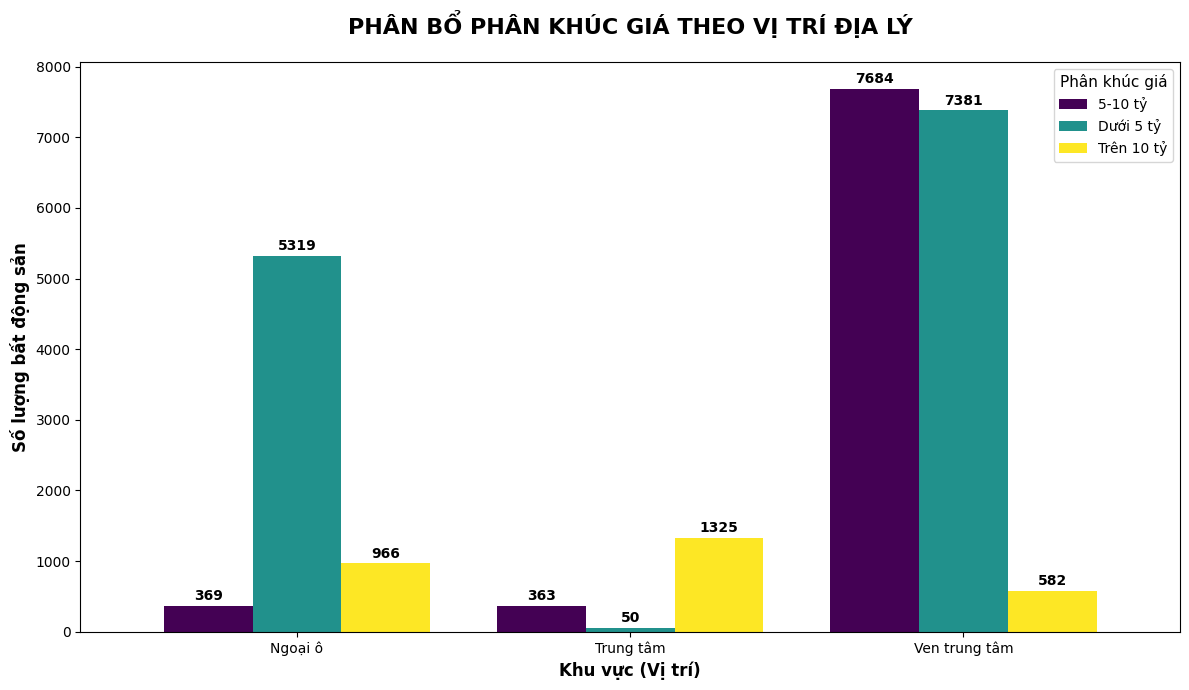

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Tạo bảng thống kê chéo giữa Vị trí và Phân loại giá
summary_table = pd.crosstab(df_clean['Vi_tri'], df_clean['Phan_Loai_Gia'])

# 2. Vẽ biểu đồ cột ghép (Grouped Bar Chart)
# Sử dụng bảng màu 'viridis' để tăng tính thẩm mỹ và dễ quan sát
ax = summary_table.plot(kind='bar', figsize=(12, 7), width=0.8, colormap='viridis')

# 3. Cấu hình chi tiết biểu đồ
plt.title('PHÂN BỔ PHÂN KHÚC GIÁ THEO VỊ TRÍ ĐỊA LÝ', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Khu vực (Vị trí)', fontsize=12, fontweight='bold')
plt.ylabel('Số lượng bất động sản', fontsize=12, fontweight='bold')
plt.xticks(rotation=0)
plt.legend(title='Phân khúc giá', title_fontsize='11', loc='upper right')

# Hiển thị số liệu cụ thể trên đầu mỗi cột để tăng tính trực quan
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(format(p.get_height(), '.0f'),
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha = 'center', va = 'center',
                    xytext = (0, 7),
                    textcoords = 'offset points',
                    fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

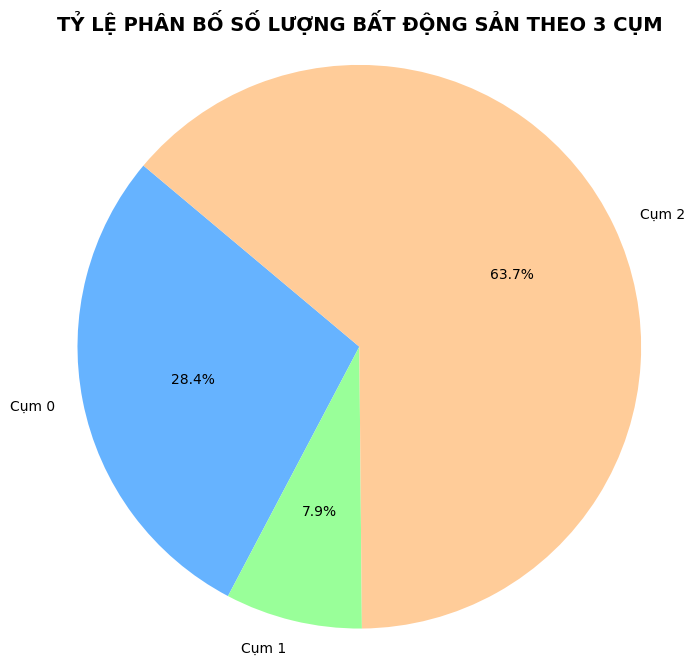

In [19]:
import matplotlib.pyplot as plt

# Đảm bảo cột Cluster đã được gán vào df_clean
# Biến clusters được lấy từ kết quả chạy K-Means ở các bước trước
df_clean['Cluster'] = clusters

# 1. Thống kê số lượng phần tử trong mỗi cụm (đã được sắp xếp theo index 0, 1, 2)
cluster_counts = df_clean['Cluster'].value_counts().sort_index()

# 2. Vẽ biểu đồ tròn thể hiện tỷ trọng các cụm
plt.figure(figsize=(8, 8))
plt.pie(cluster_counts,
        labels=[f'Cụm {i}' for i in cluster_counts.index],
        autopct='%1.1f%%',
        startangle=140,
        colors=['#66b3ff','#99ff99','#ffcc99']) # Sử dụng 3 màu đại diện cho 3 cụm

plt.title('TỶ LỆ PHÂN BỐ SỐ LƯỢNG BẤT ĐỘNG SẢN THEO 3 CỤM', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.show()

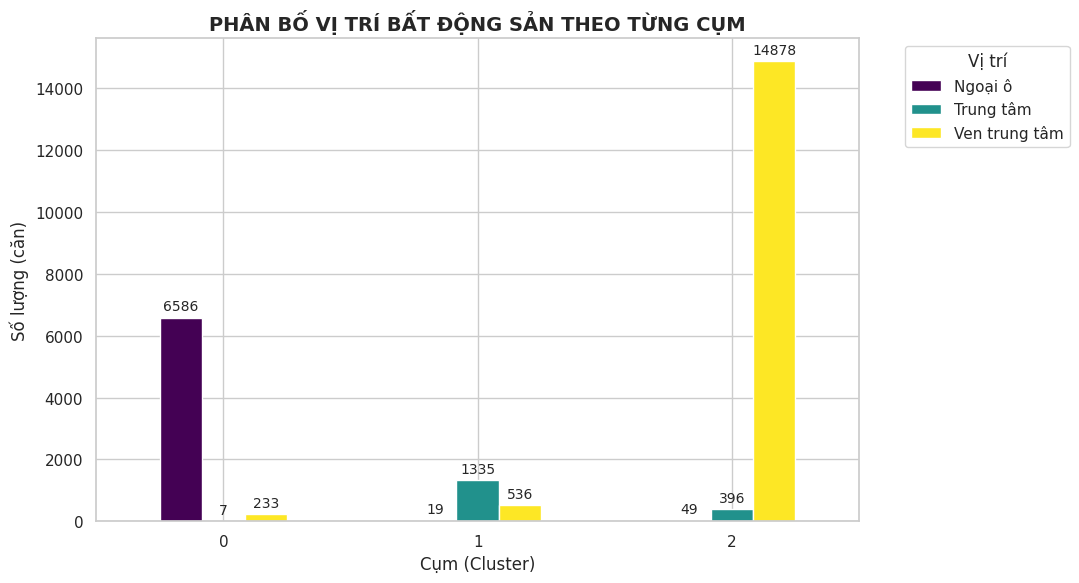

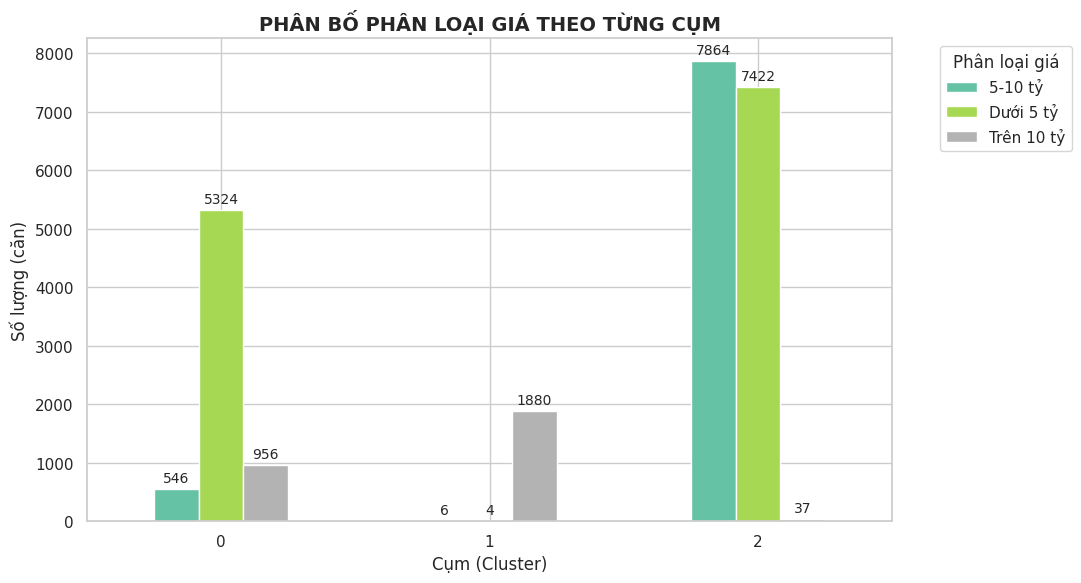

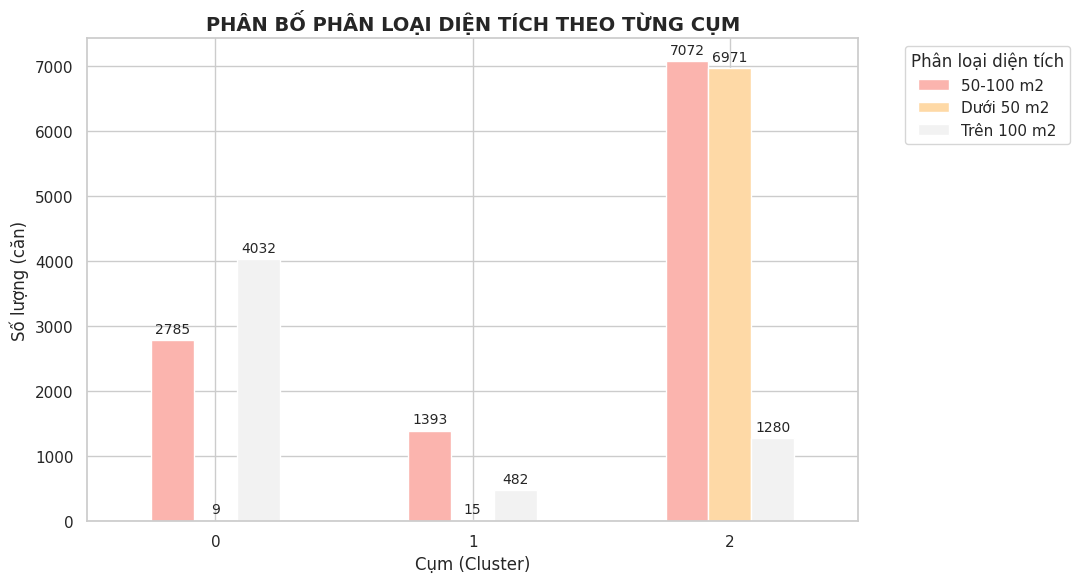

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập phong cách biểu đồ
sns.set_theme(style="whitegrid")

# Hàm phụ trợ để gắn nhãn số liệu lên đầu cột
def add_value_labels(ax):
    for container in ax.containers:
        # fmt='%d' để in số nguyên (không có số thập phân)
        ax.bar_label(container, fmt='%d', label_type='edge', padding=3, fontsize=10)

# ==========================================
# 1. Biểu đồ Phân bố Vị trí theo Cụm
# ==========================================
location_summary = pd.crosstab(df_clean['Cluster'], df_clean['Vi_tri'])
ax1 = location_summary.plot(kind='bar', figsize=(11, 6), colormap='viridis', rot=0)

plt.title('PHÂN BỐ VỊ TRÍ BẤT ĐỘNG SẢN THEO TỪNG CỤM', fontsize=14, fontweight='bold')
plt.xlabel('Cụm (Cluster)', fontsize=12)
plt.ylabel('Số lượng (căn)', fontsize=12)
plt.legend(title='Vị trí', bbox_to_anchor=(1.05, 1), loc='upper left')

add_value_labels(ax1) # Gọi hàm gắn nhãn
plt.tight_layout()
plt.show()

# ==========================================
# 2. Biểu đồ Phân bố Phân loại Giá theo Cụm
# ==========================================
price_cat_summary = pd.crosstab(df_clean['Cluster'], df_clean['Phan_Loai_Gia'])
ax2 = price_cat_summary.plot(kind='bar', figsize=(11, 6), colormap='Set2', rot=0)

plt.title('PHÂN BỐ PHÂN LOẠI GIÁ THEO TỪNG CỤM', fontsize=14, fontweight='bold')
plt.xlabel('Cụm (Cluster)', fontsize=12)
plt.ylabel('Số lượng (căn)', fontsize=12)
plt.legend(title='Phân loại giá', bbox_to_anchor=(1.05, 1), loc='upper left')

add_value_labels(ax2) # Gọi hàm gắn nhãn
plt.tight_layout()
plt.show()

# ==========================================
# 3. Biểu đồ Phân bố Phân loại Diện tích theo Cụm
# ==========================================
if 'Phan_Loai_Dien_Tich' in df_clean.columns:
    size_cat_summary = pd.crosstab(df_clean['Cluster'], df_clean['Phan_Loai_Dien_Tich'])
    ax3 = size_cat_summary.plot(kind='bar', figsize=(11, 6), colormap='Pastel1', rot=0)

    plt.title('PHÂN BỐ PHÂN LOẠI DIỆN TÍCH THEO TỪNG CỤM', fontsize=14, fontweight='bold')
    plt.xlabel('Cụm (Cluster)', fontsize=12)
    plt.ylabel('Số lượng (căn)', fontsize=12)
    plt.legend(title='Phân loại diện tích', bbox_to_anchor=(1.05, 1), loc='upper left')

    add_value_labels(ax3) # Gọi hàm gắn nhãn
    plt.tight_layout()
    plt.show()

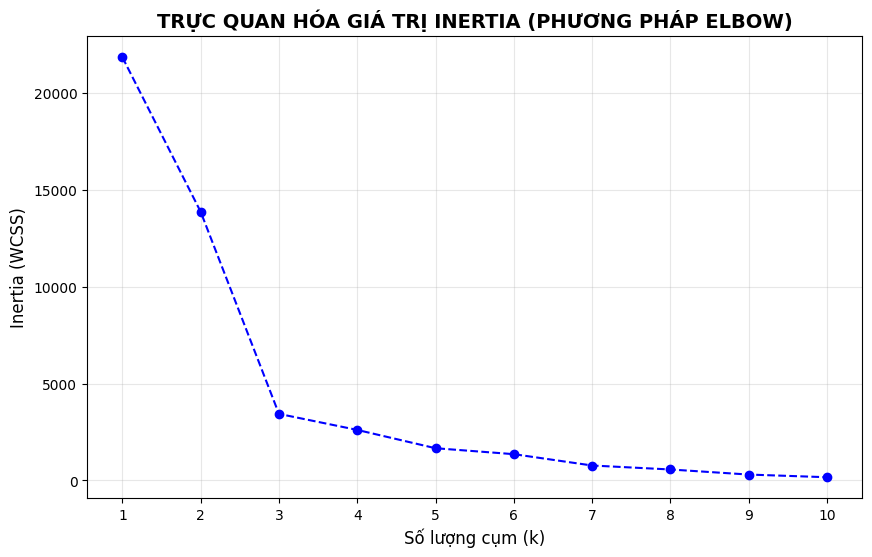

In [11]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Tính toán lại WCSS (Inertia) để đảm bảo biến tồn tại
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(house_coordinates)
    wcss.append(kmeans.inertia_)

# Trực quan hóa kết quả
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='b')
plt.title('TRỰC QUAN HÓA GIÁ TRỊ INERTIA (PHƯƠNG PHÁP ELBOW)', fontsize=14, fontweight='bold')
plt.xlabel('Số lượng cụm (k)', fontsize=12)
plt.ylabel('Inertia (WCSS)', fontsize=12)
plt.xticks(range(1, 11))
plt.grid(True, alpha=0.3)
plt.show()

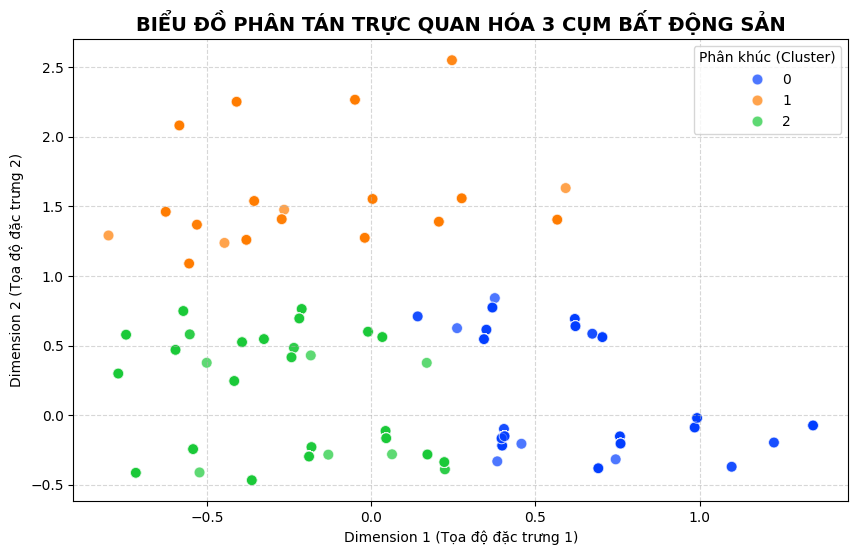

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Thêm tọa độ đặc trưng vào DataFrame để vẽ biểu đồ
df_clean['Dim_1'] = house_coordinates['Dim_1']
df_clean['Dim_2'] = house_coordinates['Dim_2']

plt.figure(figsize=(10, 6))
# Sử dụng palette màu 'bright' hoặc 'Set1' để làm nổi bật 3 cụm
sns.scatterplot(data=df_clean, x='Dim_1', y='Dim_2', hue='Cluster', palette='bright', s=60, alpha=0.7)

plt.title('BIỂU ĐỒ PHÂN TÁN TRỰC QUAN HÓA 3 CỤM BẤT ĐỘNG SẢN', fontsize=14, fontweight='bold')
plt.xlabel('Dimension 1 (Tọa độ đặc trưng 1)')
plt.ylabel('Dimension 2 (Tọa độ đặc trưng 2)')
plt.legend(title='Phân khúc (Cluster)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()